In [1]:
# Cella 1: Importazione delle Librerie

# Per prima cosa, importo tutte le librerie Python necessarie.

# pandas e' la libreria fondamentale per la manipolazione e l'analisi dei dati (DataFrame).
import pandas as pd

# plotly.express (importato come px) mi serve per creare i grafici interattivi.
import plotly.express as px

# ipywidgets mi permette di creare elementi interattivi (dashboard) come menu a tendina.
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output # Per aggiornare l'output della dashboard

print("Librerie importate correttamente.")

Librerie importate correttamente.


In [2]:
# Cella 2: Caricamento, Pulizia e Preparazione dei Dati

# Questo e' il passaggio piu' importante. Qui carico il file CSV,
# lo pulisco e lo preparo per l'analisi.

# --- CONFIGURAZIONE ---
# Specifico il nome del file CSV che ho scaricato e messo nella mia cartella.
# Deve essere esatto, incluse maiuscole/minuscole e l'estensione .csv.
NOME_FILE = "Spotify_Youtube_Dataset.csv"
# ------------------------

print(f"Caricamento del file: '{NOME_FILE}'...")

try:
    # 1. CARICAMENTO
    # Leggo il file CSV in un DataFrame di pandas.
    df_dati = pd.read_csv(NOME_FILE)
    print(f"\nSUCCESSO! Dati caricati. {len(df_dati)} righe trovate.")

    # 2. RINOMINARE LE COLONNE (Standardizzazione)
    # I nomi delle colonne nel CSV usano maiuscole (es. 'Danceability').
    # Li rinomino tutti in minuscolo (es. 'danceability') per coerenza.
    print("Standardizzazione dei nomi delle colonne (es. 'Danceability' -> 'danceability')...")
    colonne_da_rinominare = {
        'Danceability': 'danceability',
        'Energy': 'energy',
        'Valence': 'valence',
        'Tempo': 'tempo',
        'Loudness': 'loudness',
        'Acousticness': 'acousticness',
        'Speechiness': 'speechiness',
        'Views': 'views',
        'Likes': 'likes',
        'Comments': 'comments',
        'Stream': 'stream',
        'Artist': 'artist',
        'Track': 'name'
    }
    # 'errors="ignore"' assicura che il codice non fallisca se una colonna
    # nel dizionario non esiste nel file CSV.
    df_dati.rename(columns=colonne_da_rinominare, inplace=True, errors='ignore')

    # 3. DEFINIZIONE DELLE VARIABILI GLOBALI
    # Definisco queste liste per riutilizzarle facilmente in tutte le mie analisi.
    
    # Features Audio (tutte):
    FEATURES_AUDIO = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness', 'speechiness']
    
    # Features Artistiche (solo 0-1): Escludo 'tempo' e 'loudness' che hanno scale diverse.
    FEATURES_ARTISTICHE = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    
    # Metriche di Successo: Cerco le colonne di popolarita' che esistono nel DataFrame.
    METRICHE_SUCCESSO = [col for col in ['views', 'likes', 'comments', 'stream'] if col in df_dati.columns]
    
    # 4. PULIZIA DATI
    # Un'analisi e' valida solo se i dati sono puliti.
    
    # Definisco le colonne che RITENGO FONDAMENTALI per l'analisi.
    colonne_necessarie = FEATURES_AUDIO + METRICHE_SUCCESSO + ['artist', 'name']
    
    # Controllo: verifico se qualcuna di queste colonne fondamentali manca.
    colonne_mancanti = [col for col in colonne_necessarie if col not in df_dati.columns]
    
    if colonne_mancanti:
        print(f"\nERRORE: Colonne fondamentali mancanti nel mio file: {colonne_mancanti}")
        print("Controlla i nomi delle colonne nel tuo CSV e aggiorna il dizionario 'colonne_da_rinominare'.")
    else:
        # Rimuovo le righe che hanno valori 'NaN' (vuoti) nelle colonne fondamentali.
        df_dati = df_dati.dropna(subset=colonne_necessarie)
        
        print(f"Dati puliti e pronti per l'analisi. {len(df_dati)} righe valide rimaste.")
        
        # Mostro le prime 5 righe (head) dei dati puliti per conferma.
        display(df_dati[FEATURES_AUDIO + METRICHE_SUCCESSO + ['artist', 'name']].head())

except FileNotFoundError:
    print(f"\nERRORE: File '{NOME_FILE}' non trovato.")
    print("Controlla che il nome del file sia corretto e di aver avviato Jupyter dalla cartella giusta.")
except Exception as e:
    print(f"Si e' verificato un errore inaspettato durante il caricamento: {e}")

Caricamento del file: 'Spotify_Youtube_Dataset.csv'...

SUCCESSO! Dati caricati. 673 righe trovate.
Standardizzazione dei nomi delle colonne (es. 'Danceability' -> 'danceability')...
Dati puliti e pronti per l'analisi. 625 righe valide rimaste.


,danceability,energy,valence,tempo,loudness,acousticness,speechiness,views,likes,comments,stream,artist,name
0,0.818,0.705,0.772,138.559,-6.679,0.008360,0.1770,693555221.0,6220896.0,169907.0,1.040235e+09,Gorillaz,Feel Good Inc.
1,0.676,0.703,0.852,92.761,-5.815,0.086900,0.0302,72011645.0,1079128.0,31003.0,3.100837e+08,Gorillaz,Rhinestone Eyes
2,0.695,0.923,0.551,108.014,-3.930,0.042500,0.0522,8435055.0,282142.0,7399.0,6.306347e+07,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown)
3,0.689,0.739,0.578,120.423,-5.810,0.000015,0.0260,211754952.0,1788577.0,55229.0,4.346636e+08,Gorillaz,On Melancholy Hill
4,0.663,0.694,0.525,167.953,-8.627,0.025300,0.1710,618480958.0,6197318.0,155930.0,6.172597e+08,Gorillaz,Clint Eastwood


In [3]:
# Cella 3: Glossario Dettagliato - Features vs. Metriche

print("--- Spiegazione: Features vs. Metriche ---")
print("\nIn questo progetto, analizzo due tipi di dati principali:")

print("\n---------------------------------------------------------")
print("1. FEATURES (Le Caratteristiche Audio Proprietarie)")
print("---------------------------------------------------------")
print("Queste sono le 'caratteristiche intrinseche' della canzone, la sua 'impronta digitale'.")
print("Non dipendono da quanto e' popolare, ma solo da come *suona*.")
print("Sono state create da un'azienda chiamata The Echo Nest (acquistata da Spotify nel 2014),")
print("ecco perche' sono associate all'ecosistema di Spotify.")

print("\nEcco i parametri e le scale di misurazione di ogni feature:")
print("\n[Rapporti 0.0 - 1.0]")
print("-----------------")
print("   - danceability (0.0 - 1.0):")
print("     Non misura solo 'se' si puo' ballare, ma 'quanto e' adatta' a ballare.")
print("     Si basa su una combinazione di elementi come la regolarita' del ritmo,")
print("     la stabilita' del tempo e la forza della battuta ('beat strength').")
print("     Un valore di 0.0 e' (quasi) non ballabile, 1.0 e' perfettamente ballabile.")
      
print("\n   - energy (0.0 - 1.0):")
print("     Rappresenta una misura percettiva di intensita' e attivita'.")
print("     Le tracce 'energetiche' (vicine a 1.0) sono tipicamente veloci, forti e rumorose (es. Death Metal).")
print("     Le tracce 'a bassa energia' (vicine a 0.0) sono calme e morbide (es. una sonata di Bach).")

print("\n   - valence (0.0 - 1.0):")
print("     Misura la 'positivita'' musicale trasmessa dalla traccia.")
print("     Valori alti (vicini a 1.0) suonano piu' positivi (es. felici, euforici, allegri).")
print("     Valori bassi (vicini a 0.0) suonano piu' negativi (es. tristi, arrabbiati, depressi).")

print("\n   - acousticness (0.0 - 1.0):")
print("     Una misura di confidenza se la traccia e' acustica.")
print("     1.0 rappresenta un'alta confidenza che la traccia sia puramente acustica (es. voce e chitarra).")

print("\n   - speechiness (0.0 - 1.0):")
print("     Rileva la presenza di parole parlate nella traccia.")
print("     - Valori sopra 0.66: La traccia e' quasi certamente interamente parlata (es. podcast, audiolibro).")
print("     - Valori tra 0.33 e 0.66: La traccia puo' contenere sia musica che parlato (es. Rap, Hip-Hop).")
print("     - Valori sotto 0.33: La traccia e' quasi certamente musica e canzoni non-rap.")

print("\n[Valori Assoluti (Scale diverse)]")
print("-----------------")
print("   - loudness (dB):")
print("     Il volume (loudness) medio della traccia in decibel (dB).")
print("     I valori sono tipicamente tra -60 dB (molto silenzioso) e 0 dB (molto forte).")

print("   - tempo (BPM):")
print("     Il tempo stimato della traccia in Battiti Per Minuto (BPM).")


print("\n---------------------------------------------------------")
print("2. METRICHE (Le Metriche di Successo)")
print("---------------------------------------------------------")
print("Questi sono i numeri che misurano la popolarita' e l'engagement,")
print("ovvero il risultato della canzone sul mercato.")
print("   - stream: Quanti ascolti ha su Spotify.")
print("   - views:  Quante visualizzazioni ha su YouTube.")
print("   - likes:  Quanti 'Mi Piace' ha su YouTube.")
print("\nIl mio obiettivo e' capire se c'e' una relazione tra le FEATURES (come suona) e le METRICHE (il successo).")

--- Spiegazione: Features vs. Metriche ---

In questo progetto, analizzo due tipi di dati principali:

---------------------------------------------------------
1. FEATURES (Le Caratteristiche Audio Proprietarie)
---------------------------------------------------------
Queste sono le 'caratteristiche intrinseche' della canzone, la sua 'impronta digitale'.
Non dipendono da quanto e' popolare, ma solo da come *suona*.
Sono state create da un'azienda chiamata The Echo Nest (acquistata da Spotify nel 2014),
ecco perche' sono associate all'ecosistema di Spotify.

Ecco i parametri e le scale di misurazione di ogni feature:

[Rapporti 0.0 - 1.0]
-----------------
   - danceability (0.0 - 1.0):
     Non misura solo 'se' si puo' ballare, ma 'quanto e' adatta' a ballare.
     Si basa su una combinazione di elementi come la regolarita' del ritmo,
     la stabilita' del tempo e la forza della battuta ('beat strength').
     Un valore di 0.0 e' (quasi) non ballabile, 1.0 e' perfettamente ballabile


--- Analisi 1: Profilo Audio Medio (Features 0-1) ---


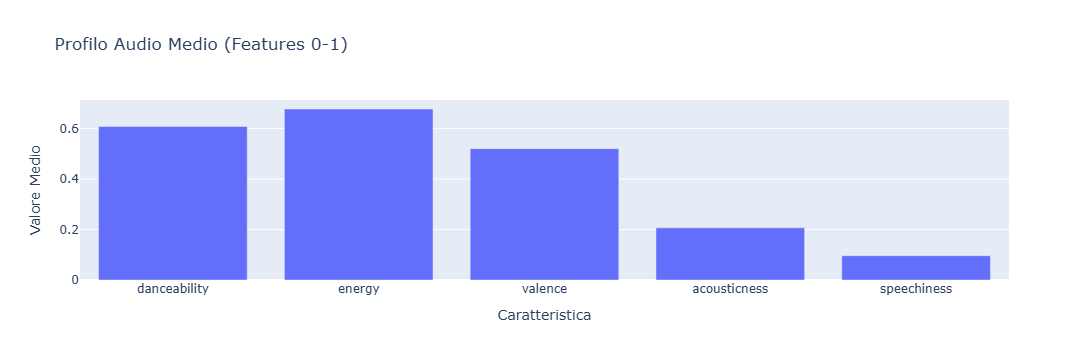


--- Interpretazione Grafico 1: Profilo Audio Medio ---
Da questo grafico a barre, posso vedere immediatamente che in questo dataset le canzoni hanno, in media,
valori alti per 'energy' e 'danceability' (entrambi sopra 0.6).
Al contrario, 'acousticness' (circa 0.2) e 'speechiness' (circa 0.1) sono molto bassi.
Questo mi suggerisce che il dataset e' composto principalmente da musica pop, elettronica o da club,
piuttosto che da musica acustica o hip-hop 'parlato'.

--- Analisi 2: Danceability vs Views (Scala Logaritmica) ---


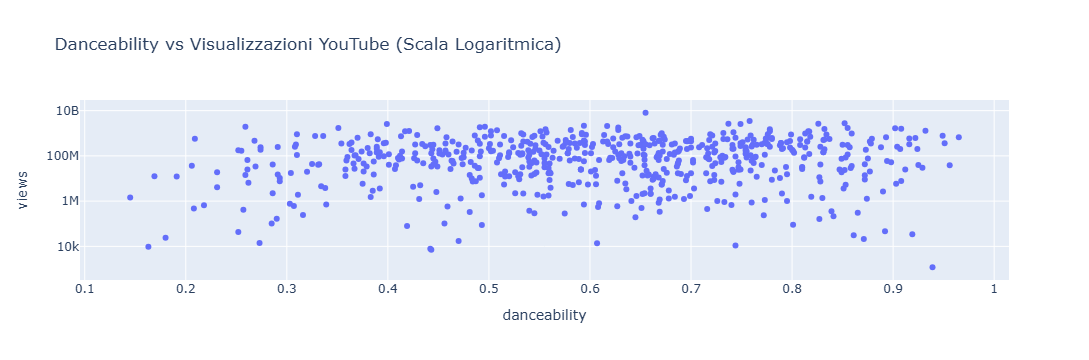


--- Interpretazione Grafico 2: Danceability vs. Views ---
Questo grafico cerca una correlazione tra ballabilita' e successo su YouTube.
Come noto, i punti formano una 'nuvola' sparsa e non una linea chiara.
Posso vedere canzoni con bassa 'danceability' (a sinistra) che hanno miliardi di views,
e canzoni con alta 'danceability' (a destra) che ne hanno poche.
Conclusione: La 'danceability' da sola NON e' un indicatore affidabile del successo di una canzone.


In [4]:
# Cella 4: Analisi 1 - Profilo Audio e Correlazione Views

# Questa cella esegue due analisi visive di base per ottenere
# una prima comprensione dei dati.

if 'df_dati' in locals():
    
    # --- Q1: Profilo Audio Medio (Features Artistiche 0-1) ---
    print("\n--- Analisi 1: Profilo Audio Medio (Features 0-1) ---")
    
    # Calcolo la media solo delle features "artistiche" (scala 0-1)
    # per evitare che 'tempo' (es. 120) "schiacci" il grafico.
    df_medie_artistiche = df_dati[FEATURES_ARTISTICHE].mean().reset_index()
    df_medie_artistiche.columns = ['Caratteristica', 'Valore Medio']
    
    fig1 = px.bar(df_medie_artistiche, x='Caratteristica', y='Valore Medio', title="Profilo Audio Medio (Features 0-1)")
    fig1.show()
    
    print("\n--- Interpretazione Grafico 1: Profilo Audio Medio ---")
    print("Da questo grafico a barre, posso vedere immediatamente che in questo dataset le canzoni hanno, in media,")
    print("valori alti per 'energy' e 'danceability' (entrambi sopra 0.6).")
    print("Al contrario, 'acousticness' (circa 0.2) e 'speechiness' (circa 0.1) sono molto bassi.")
    print("Questo mi suggerisce che il dataset e' composto principalmente da musica pop, elettronica o da club,")
    print("piuttosto che da musica acustica o hip-hop 'parlato'.")


    # --- Q2: Danceability vs Views (Scala Logaritmica) ---
    if 'views' in METRICHE_SUCCESSO:
        print("\n--- Analisi 2: Danceability vs Views (Scala Logaritmica) ---")
        
        # Creo uno scatter plot (grafico a dispersione).
        # Uso 'log_y=True' per applicare una scala logaritmica all'asse Y.
        # Questo e' FONDAMENTALE per gestire gli "outlier" (canzoni superstar
        # con miliardi di views) che altrimenti schiaccerebbero tutti gli altri
        # dati sulla linea dello zero.
        
        fig2 = px.scatter(df_dati,
                         x='danceability',
                         y='views',
                         log_y=True, # Applica la scala logaritmica
                         title="Danceability vs Visualizzazioni YouTube (Scala Logaritmica)",
                         hover_name='name' # Passa il mouse per vedere il titolo della canzone
                        )
        fig2.show()
        
        print("\n--- Interpretazione Grafico 2: Danceability vs. Views ---")
        print("Questo grafico cerca una correlazione tra ballabilita' e successo su YouTube.")
        print("Come noto, i punti formano una 'nuvola' sparsa e non una linea chiara.")
        print("Posso vedere canzoni con bassa 'danceability' (a sinistra) che hanno miliardi di views,")
        print("e canzoni con alta 'danceability' (a destra) che ne hanno poche.")
        print("Conclusione: La 'danceability' da sola NON e' un indicatore affidabile del successo di una canzone.")

    
else:
    print("ERRORE: 'df_dati' non trovato. Esegui prima la Cella 2.")


--- Analisi 3: Matrice di Correlazione ---
Genero una heatmap per vedere le correlazioni tra tutte le features e le metriche.
Un valore vicino a 1.0 (colore caldo) significa una forte correlazione positiva.
Un valore vicino a 0.0 (colore neutro) significa nessuna correlazione.


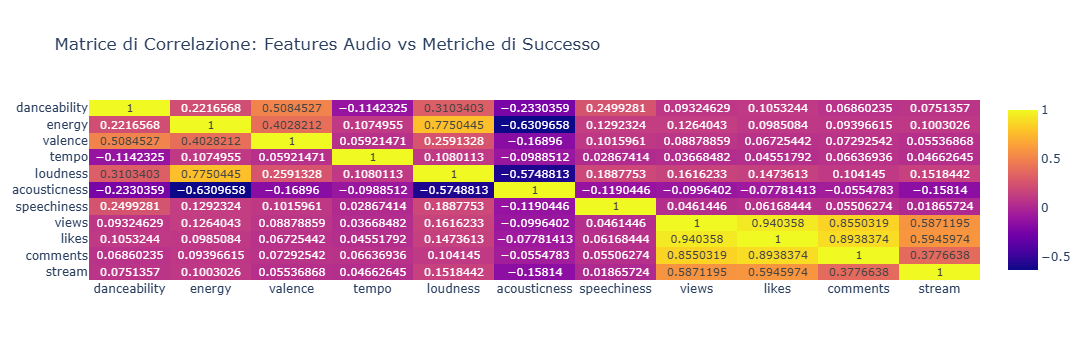


--- Interpretazione Grafico 3: Heatmap di Correlazione ---
Questa griglia e' il mio riassunto statistico.
Guardando le righe 'views', 'likes' e 'stream', noto subito che 'loudness' (volume) ed 'energy'
hanno le correlazioni positive piu' alte (anche se non altissime, circa 0.1-0.2).
Questo suggerisce che le canzoni piu' 'forti' ed energetiche tendono ad avere piu' successo.
Noto anche una forte correlazione positiva tra 'energy' e 'loudness' (0.74), il che ha senso: le canzoni piu' energetiche sono anche piu' rumorose.
Confermo che 'danceability' e 'valence' hanno correlazioni molto vicine a zero con il successo.


In [5]:
# Cella 5: Analisi 2 - Matrice di Correlazione (Heatmap)

# Per vedere *tutte* le correlazioni in un colpo solo, genero una "heatmap".
# Questa e' una griglia che usa i colori per mostrare la relazione
# tra ogni variabile numerica (da -1 a +1).

if 'df_dati' in locals() and METRICHE_SUCCESSO:
    print(f"\n--- Analisi 3: Matrice di Correlazione ---")
    print("Genero una heatmap per vedere le correlazioni tra tutte le features e le metriche.")
    print("Un valore vicino a 1.0 (colore caldo) significa una forte correlazione positiva.")
    print("Un valore vicino a 0.0 (colore neutro) significa nessuna correlazione.")
    
    colonne_per_matrice = FEATURES_AUDIO + METRICHE_SUCCESSO
    df_matrice = df_dati[colonne_per_matrice].copy()
    
    # .corr() calcola la matrice
    corr_matrix = df_matrice.corr()
    
    # px.imshow la disegna
    fig_heatmap = px.imshow(corr_matrix, text_auto=True, aspect="auto",
                            title="Matrice di Correlazione: Features Audio vs Metriche di Successo"
                           )
    fig_heatmap.show()
    
    print("\n--- Interpretazione Grafico 3: Heatmap di Correlazione ---")
    print("Questa griglia e' il mio riassunto statistico.")
    print("Guardando le righe 'views', 'likes' e 'stream', noto subito che 'loudness' (volume) ed 'energy'")
    print("hanno le correlazioni positive piu' alte (anche se non altissime, circa 0.1-0.2).")
    print("Questo suggerisce che le canzoni piu' 'forti' ed energetiche tendono ad avere piu' successo.")
    print("Noto anche una forte correlazione positiva tra 'energy' e 'loudness' (0.74), il che ha senso: le canzoni piu' energetiche sono anche piu' rumorose.")
    print("Confermo che 'danceability' e 'valence' hanno correlazioni molto vicine a zero con il successo.")

else:
    print("ERRORE: Dati non pronti per la Heatmap. Esegui la Cella 2.")


--- Analisi 4: Confronto Profilo Audio 'Hit' (Top 10%) vs. 'Flop' (Bottom 10%) ---
Canzoni 'Hit' (Top 10%): 63, Canzoni 'Flop' (Bottom 10%): 63


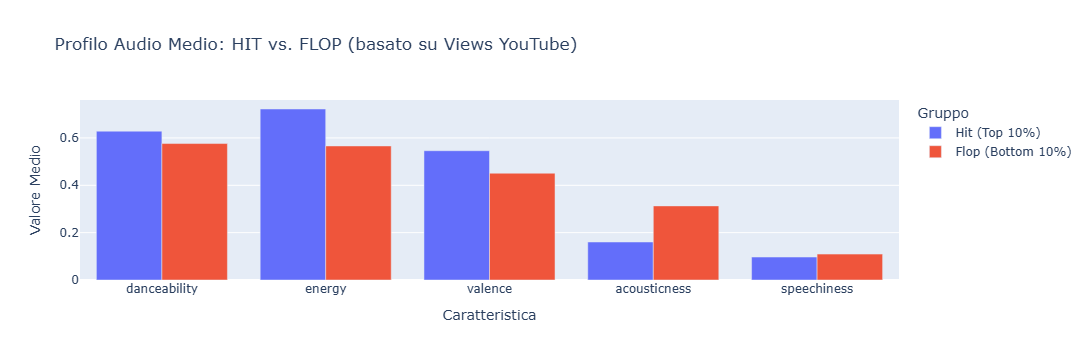


--- Interpretazione Grafico 4: Hit vs. Flop ---
Questa e' un'analisi molto chiara. Posso vedere le barre 'Hit' e 'Flop' fianco a fianco.
Noto che per 'danceability' e 'valence' (umore), le barre sono quasi identiche.
Questo conferma che essere felici o ballabili non distingue una hit da un flop.
La differenza piu' grande e' in 'acousticness': le canzoni 'Hit' sono significativamente
meno acustiche (barra piu' bassa) rispetto ai 'Flop'. Questo rafforza la mia teoria
che le canzoni di successo in questo dataset sono molto prodotte ed elettroniche.


In [6]:
# Cella 6: Analisi 3 - Hit vs. Flop (Analisi Comparativa)

# Rispondo alla domanda: "Le canzoni di successo hanno un'impronta audio diversa
# da quelle che falliscono?"

# Per farlo, definisco "Hit" come il 10% superiore per 'views'
# e "Flop" come il 10% inferiore.

if 'views' in METRICHE_SUCCESSO:
    print("\n--- Analisi 4: Confronto Profilo Audio 'Hit' (Top 10%) vs. 'Flop' (Bottom 10%) ---")
    
    # 1. Definisco "Hit" e "Flop" usando i quantili (percentili)
    quantile_90 = df_dati['views'].quantile(0.90)
    quantile_10 = df_dati['views'].quantile(0.10)

    # 2. Creo i due gruppi
    df_hits = df_dati[df_dati['views'] >= quantile_90]
    df_flops = df_dati[df_dati['views'] <= quantile_10]
    
    print(f"Canzoni 'Hit' (Top 10%): {len(df_hits)}, Canzoni 'Flop' (Bottom 10%): {len(df_flops)}")

    # 3. Calcolo i profili medi
    mean_hits = df_hits[FEATURES_ARTISTICHE].mean().reset_index()
    mean_flops = df_flops[FEATURES_ARTISTICHE].mean().reset_index()

    mean_hits['Gruppo'] = 'Hit (Top 10%)'
    mean_flops['Gruppo'] = 'Flop (Bottom 10%)'

    # 4. Unisco le tabelle per il grafico
    df_compare = pd.concat([mean_hits, mean_flops])
    df_compare.columns = ['Caratteristica', 'Valore Medio', 'Gruppo']

    # 5. Creo il grafico (barmode='group')
    fig_compare = px.bar(df_compare,
                         x='Caratteristica',
                         y='Valore Medio',
                         color='Gruppo',
                         barmode='group', # Barre raggruppate
                         title="Profilo Audio Medio: HIT vs. FLOP (basato su Views YouTube)")
    fig_compare.show()
    
    print("\n--- Interpretazione Grafico 4: Hit vs. Flop ---")
    print("Questa e' un'analisi molto chiara. Posso vedere le barre 'Hit' e 'Flop' fianco a fianco.")
    print("Noto che per 'danceability' e 'valence' (umore), le barre sono quasi identiche.")
    print("Questo conferma che essere felici o ballabili non distingue una hit da un flop.")
    print("La differenza piu' grande e' in 'acousticness': le canzoni 'Hit' sono significativamente")
    print("meno acustiche (barra piu' bassa) rispetto ai 'Flop'. Questo rafforza la mia teoria")
    print("che le canzoni di successo in questo dataset sono molto prodotte ed elettroniche.")

else:
    print("ERRORE: Colonna 'views' non trovata per l'analisi Hit vs. Flop.")


--- Analisi 5: Top 10 Canzoni (per Stream Spotify) con le loro Features ---


,name,artist,stream,danceability,energy,valence
140,lovely (with Khalid),Khalid,2.110574e+09,0.351,0.296,0.120
43,Something Just Like This,Coldplay,2.030826e+09,0.617,0.635,0.446
569,Wonderwall - Remastered,Oasis,1.568357e+09,0.375,0.893,0.434
124,Till I Collapse,Eminem,1.548872e+09,0.548,0.847,0.100
254,Cheap Thrills,Sia,1.538447e+09,0.628,0.698,0.732
365,Despacito,Daddy Yankee,1.506598e+09,0.655,0.797,0.839
40,Yellow,Coldplay,1.483622e+09,0.429,0.661,0.285
44,The Scientist,Coldplay,1.465981e+09,0.557,0.442,0.213
121,Without Me,Eminem,1.457352e+09,0.908,0.669,0.662
60,In the End,Linkin Park,1.444842e+09,0.556,0.864,0.400



--- Analisi 6: Top 10 Artisti (per Stream Totali nel Dataset) ---


,artist,total_streams
0,Coldplay,1.177848e+10
1,Khalid,1.138684e+10
2,Eminem,9.748588e+09
3,Sia,7.368344e+09
4,Red Hot Chili Peppers,6.796467e+09
5,Kanye West,6.517926e+09
6,Linkin Park,6.362409e+09
7,AC/DC,5.941406e+09
8,Elton John,5.462062e+09
9,Beyoncé,5.178560e+09


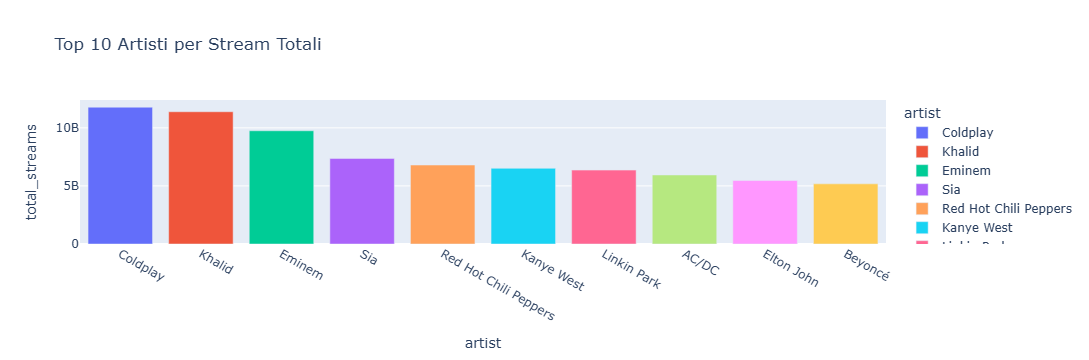


--- Interpretazione Analisi 5 e 6: Top 10 ---
Queste tabelle e il grafico a barre mi danno un contesto su chi siano i 'pesi massimi'
che sto analizzando. Guardare le loro features audio (nella tabella Top 10 Canzoni)
mi conferma che le canzoni piu' popolari in assoluto hanno valori alti di 'energy'
e 'danceability' e valori molto bassi di 'acousticness'.


In [7]:
# Cella 7: Analisi 4 - Classifiche Top 10

# Ora creo delle classifiche "assolute", usando 'stream' (ascolti su Spotify)
# come metrica principale di successo.

if 'stream' in METRICHE_SUCCESSO:
    
    # --- Top 10 Canzoni ---
    print("\n--- Analisi 5: Top 10 Canzoni (per Stream Spotify) con le loro Features ---")
    
    colonne_da_mostrare = ['name', 'artist', 'stream', 'danceability', 'energy', 'valence']
    # Ordino il DataFrame per 'stream' e prendo i primi 10 (.head(10))
    df_top_songs = df_dati.sort_values(by='stream', ascending=False)
    display(df_top_songs[colonne_da_mostrare].head(10))
    
    # --- Top 10 Artisti ---
    print("\n--- Analisi 6: Top 10 Artisti (per Stream Totali nel Dataset) ---")
    
    # Per ottenere questa classifica, devo:
    # 1. Raggruppare per artista (.groupby('artist'))
    # 2. Sommare i loro stream (.sum())
    # 3. Ordinare e prendere i primi 10 (.nlargest(10))
    df_artisti_stream = df_dati.groupby('artist')['stream'].sum().nlargest(10).reset_index()
    df_artisti_stream.columns = ['artist', 'total_streams']
    display(df_artisti_stream)
    
    fig_artisti = px.bar(df_artisti_stream, x='artist', y='total_streams', 
                         title="Top 10 Artisti per Stream Totali", color='artist')
    fig_artisti.show()
    
    print("\n--- Interpretazione Analisi 5 e 6: Top 10 ---")
    print("Queste tabelle e il grafico a barre mi danno un contesto su chi siano i 'pesi massimi'")
    print("che sto analizzando. Guardare le loro features audio (nella tabella Top 10 Canzoni)")
    print("mi conferma che le canzoni piu' popolari in assoluto hanno valori alti di 'energy'")
    print("e 'danceability' e valori molto bassi di 'acousticness'.")

else:
    print("ERRORE: Colonna 'stream' non trovata. Impossibile calcolare la Top 10.")

In [8]:
# Cella 8: Analisi Finale - Dashboard Interattiva "Artist Wrapped"

# Come analisi finale, costruisco una dashboard interattiva "Artist Wrapped".
# L'idea e' di permettermi di esplorare i dati.

# Creo un menu a tendina (Dropdown) con la lista di tutti gli artisti.
# Definisco una funzione (on_artist_change) che si attiva
# ogni volta che cambio l'artista nel menu.

# Questa funzione:
# 1. Pulisce l'output precedente.
# 2. Filtra il DataFrame solo per l'artista selezionato.
# 3. Genera 3 analisi al volo: il profilo audio medio dell'artista,
#    le sue top 5 canzoni su Spotify e le sue top 5 canzoni su YouTube.

if 'df_dati' in locals() and 'artist' in df_dati.columns and 'stream' in METRICHE_SUCCESSO:
    
    print("\n--- Analisi 7: Dashboard 'Artist Wrapped' ---")
    print("Scegli un artista dal menu qui sotto per generare il suo 'Wrapped'.")
    
    # 1. Preparo la lista di artisti unici per il menu
    lista_artisti = sorted(df_dati['artist'].unique())

    # --- 2. Creo i Widget (L'interfaccia) ---
    artist_wrapped_widget = widgets.Dropdown(
        options=lista_artisti,
        value=lista_artisti[0],
        description='Artista:',
        layout={'width': '400px'}
    )
    output_wrapped = widgets.Output() # Il contenitore per i grafici

    # --- 3. Definisco la Funzione di Aggiornamento ---
    def on_artist_change(change):
        selected_artist = change['new']
        
        # 'with output_wrapped:' disegna tutto dentro il contenitore
        with output_wrapped:
            clear_output(wait=True) # Pulisce l'output precedente
            
            print(f"--- Wrapped per: {selected_artist.upper()} ---")
            
            # Filtro il DataFrame per l'artista
            df_artist = df_dati[df_dati['artist'] == selected_artist]
            
            # Analisi 1: Profilo Audio
            print("\nProfilo Audio Medio (L'Aura dell'Artista):")
            df_profilo = df_artist[FEATURES_ARTISTICHE].mean().reset_index()
            df_profilo.columns = ['Caratteristica', 'Valore Medio']
            fig = px.bar(df_profilo, x='Caratteristica', y='Valore Medio', 
                         title=f"Profilo Audio di '{selected_artist}'")
            display(fig)
            
            # Analisi 2: Top Canzoni per Stream (Spotify)
            if 'stream' in df_artist.columns:
                print("\nTop Canzoni (per Stream Spotify):")
                colonne_canzoni = ['name', 'stream', 'danceability', 'energy']
                df_top_songs_s = df_artist.sort_values(by='stream', ascending=False)[colonne_canzoni].head(5)
                display(df_top_songs_s)
            
            # Analisi 3: Top Canzoni per Views (YouTube)
            if 'views' in df_artist.columns:
                print("\nTop Canzoni (per Views YouTube):")
                colonne_canzoni_yt = ['name', 'views', 'likes', 'danceability']
                df_top_songs_y = df_artist.sort_values(by='views', ascending=False)[colonne_canzoni_yt].head(5)
                display(df_top_songs_y)
            
    # --- 4. Colleghiamo il Widget alla Funzione ---
    artist_wrapped_widget.observe(on_artist_change, names='value')
    
    # --- 5. Mostriamo l'interfaccia ---
    display(artist_wrapped_widget, output_wrapped)
    on_artist_change({'new': lista_artisti[0]}) # Mostra il primo artista

else:
    print("ERRORE: Dati non pronti per il Wrapped.")
    print("Assicurati che le colonne 'artist' e 'stream' siano corrette nella Cella 2.")


--- Analisi 7: Dashboard 'Artist Wrapped' ---
Scegli un artista dal menu qui sotto per generare il suo 'Wrapped'.


Dropdown(description='Artista:', layout=Layout(width='400px'), options=('21 Savage', '2Pac', '50 Cent', 'A.R. …

Output()